# Entrenamiento Local — Aprendizaje Federado con MNIST

Este notebook es ejecutado por **cada cliente** de forma independiente.  
Contiene:
1. Carga de los datos locales (partición confidencial del cliente)
2. Carga o inicialización del modelo global (`TheModel.py`)
3. **Training loop local** con Early Stopping
4. **Curvas de aprendizaje** (loss y accuracy)
5. **Classification Report** y matriz de confusión
6. Guardado de los pesos locales para enviarlos al servidor federado

> ⚠️ **Sólo comparte** el archivo de pesos resultante (`client_X_weights.npz`) con el coordinador, **nunca** tus datos.

---
### ⚠️ Nota importante sobre la semilla global

En aprendizaje federado, **todos los clientes deben partir de la misma inicialización de pesos**.
Si cada cliente crea el modelo con pesos aleatorios distintos, las neuronas de cada capa aprenden
a representar los mismos patrones pero en *posiciones distintas* (permutation invariance).
Al promediar (FedAvg), los pesos de posiciones incompatibles se mezclan y el resultado es ruido.

La solución es que todos usen `INIT_SEED = 0` (o cualquier valor fijo compartido) **antes** de
llamar a `build_model()`. Esto no afecta la aleatoridad del training (cada cliente tiene datos
distintos), sólo garantiza que el punto de partida sea idéntico.

## 0. Configuración e imports

In [28]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Importar nuestro modelo global
from TheModel import build_model

# ── Configuración ───────────────────────────────────────
CLIENT_ID       = 3          # ← Cambiar al ID de tu partición (0, 1, 2 o 3)
DATA_DIR        = "client_data"  # carpeta con los .npz
GLOBAL_WEIGHTS  = None       # ruta al .weights.h5 del modelo global (None = primera ronda)
EPOCHS          = 7
BATCH_SIZE      = 64
LEARNING_RATE   = 0.001
PATIENCE        = 5          # Early stopping

# ── Semilla de inicialización ────────────────────────────
# CRÍTICO: todos los clientes deben usar el MISMO valor.
# Solo se aplica cuando GLOBAL_WEIGHTS=None (primera ronda).
# En rondas posteriores, la inicialización viene del modelo global.
INIT_SEED = 0

print(f"TensorFlow {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
print(f"Cliente ID: {CLIENT_ID}")

TensorFlow 2.16.1
GPU disponible: []
Cliente ID: 3


## 1. Carga de datos locales

Train: (14995, 28, 28, 1)  |  Test: (2497, 28, 28, 1)
Distribución train: {0: 1480, 1: 1685, 2: 1489, 3: 1532, 4: 1460, 5: 1355, 6: 1479, 7: 1566, 8: 1462, 9: 1487}


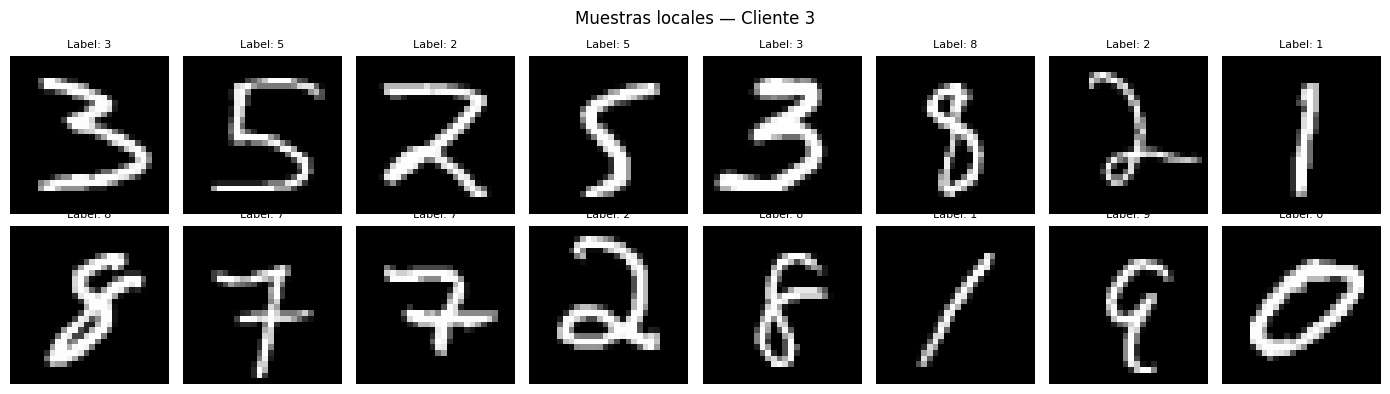

In [29]:
train_path = os.path.join(DATA_DIR, f"client_{CLIENT_ID}_train.npz")
test_path  = os.path.join(DATA_DIR, f"client_{CLIENT_ID}_test.npz")

train_data = np.load(train_path)
test_data  = np.load(test_path)

x_train, y_train = train_data["x"], train_data["y"]
x_test,  y_test  = test_data["x"],  test_data["y"]

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")
print(f"Distribución train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# Visualizar algunas muestras
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, :, :, 0], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Muestras locales — Cliente {CLIENT_ID}", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Inicialización del modelo

In [30]:
if GLOBAL_WEIGHTS and os.path.exists(GLOBAL_WEIGHTS):
    # Ronda 2+: cargar el modelo global del coordinador.
    # No se necesita semilla fija porque los pesos vienen del servidor.
    model = build_model(learning_rate=LEARNING_RATE)
    model.load_weights(GLOBAL_WEIGHTS)
    print(f"✅ Pesos globales cargados desde: {GLOBAL_WEIGHTS}")
else:
    # Ronda 1: todos los clientes deben construir el modelo con la
    # MISMA semilla para garantizar inicialización idéntica.
    # Sin esto, FedAvg promedia pesos desalineados → resultado aleatorio.
    tf.keras.utils.set_random_seed(INIT_SEED)
    model = build_model(learning_rate=LEARNING_RATE)
    print(f"ℹ️  Primera ronda — pesos inicializados con semilla {INIT_SEED}")
    print(f"   Asegúrate de que todos los clientes usen INIT_SEED = {INIT_SEED}")

model.summary()

ℹ️  Primera ronda — pesos inicializados con semilla 0
   Asegúrate de que todos los clientes usen INIT_SEED = 0


Model: "MiniResNet_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 28, 28,    │        288 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 28, 28,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 28, 28,    │          0 │ stem_bn[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 28, 28,    │      9,216 │ stem_relu[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_24 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 28, 28,    │      9,216 │ re_lu_24[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_25 (ReLU)     │ (None, 28, 28,    │          0 │ add_12[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 14, 14,    │     18,432 │ re_lu_25[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 14, 14,    │     36,864 │ re_lu_26[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 14, 14,    │      2,048 │ re_lu_25[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_33[0][0] 

 Total params: 400,554 (1.53 MB)

 Trainable params: 398,698 (1.52 MB)

 Non-trainable params: 1,856 (7.25 KB)

## 3. Training Loop Local

In [31]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEntrenamiento finalizado en {len(history.history['loss'])} épocas.")

Epoch 1/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 96s 409ms/step - accuracy: 0.6326 - loss: 1.1254 - val_accuracy: 0.2027 - val_loss: 3.2646 - learning_rate: 0.0010
Epoch 2/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 85s 404ms/step - accuracy: 0.9618 - loss: 0.1469 - val_accuracy: 0.7420 - val_loss: 0.7165 - learning_rate: 0.0010
Epoch 3/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 88s 418ms/step - accuracy: 0.9731 - loss: 0.0950 - val_accuracy: 0.8800 - val_loss: 0.4174 - learning_rate: 0.0010
Epoch 4/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 435ms/step - accuracy: 0.9798 - loss: 0.0669 - val_accuracy: 0.9560 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 5/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 94s 443ms/step - accuracy: 0.9833 - loss: 0.0598 - val_accuracy: 0.9687 - val_loss: 0.0956 - learning_rate: 0.0010
Epoch 6/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 93s 438ms/step - accuracy: 0.9880 - loss: 0.0407 - val_accuracy: 0.9767 - val_loss: 0.0845 - learning_rate: 0.0010
Epoch 7/7
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 356ms/step - accuracy: 0.9899 - l

## 4. Curvas de Aprendizaje

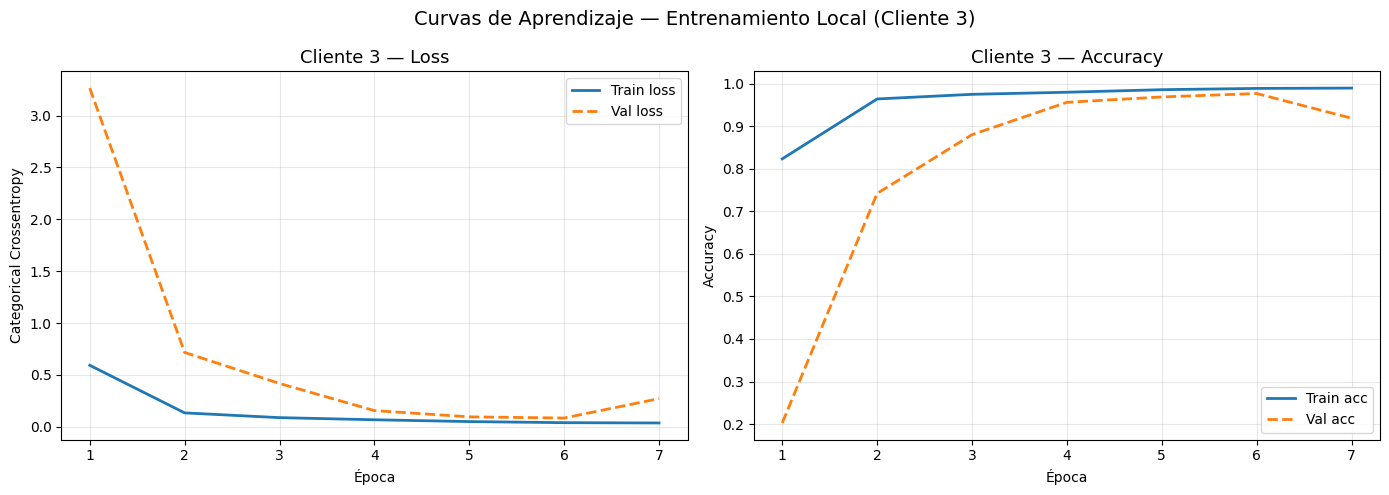

Gráfica guardada como learning_curves_client_3.png


In [32]:
def plot_learning_curves(history, client_id):
    epochs_ran = range(1, len(history.history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_ran, history.history["loss"],     label="Train loss",      linewidth=2)
    axes[0].plot(epochs_ran, history.history["val_loss"], label="Val loss",   linestyle="--", linewidth=2)
    axes[0].set_title(f"Cliente {client_id} — Loss", fontsize=13)
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Categorical Crossentropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_ran, history.history["accuracy"],     label="Train acc",      linewidth=2)
    axes[1].plot(epochs_ran, history.history["val_accuracy"], label="Val acc",   linestyle="--", linewidth=2)
    axes[1].set_title(f"Cliente {client_id} — Accuracy", fontsize=13)
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"Curvas de Aprendizaje — Entrenamiento Local (Cliente {client_id})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"learning_curves_client_{client_id}.png", dpi=150)
    plt.show()
    print(f"Gráfica guardada como learning_curves_client_{client_id}.png")


plot_learning_curves(history, CLIENT_ID)

## 5. Evaluación sobre el conjunto de prueba

In [33]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Test Loss    : 0.0860
Test Accuracy: 0.9728  (97.28%)


In [34]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = [str(i) for i in range(10)]

print("\n" + "="*55)
print(f"  Classification Report — Cliente {CLIENT_ID}")
print("="*55)
print(classification_report(y_test, y_pred, target_names=class_names))


  Classification Report — Cliente 3
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       245
           1       1.00      1.00      1.00       283
           2       0.96      0.99      0.97       258
           3       1.00      0.94      0.97       252
           4       1.00      0.97      0.98       245
           5       0.95      1.00      0.98       223
           6       0.99      0.98      0.99       239
           7       0.93      0.99      0.96       257
           8       0.97      0.95      0.96       243
           9       0.99      0.90      0.95       252

    accuracy                           0.97      2497
   macro avg       0.97      0.97      0.97      2497
weighted avg       0.97      0.97      0.97      2497



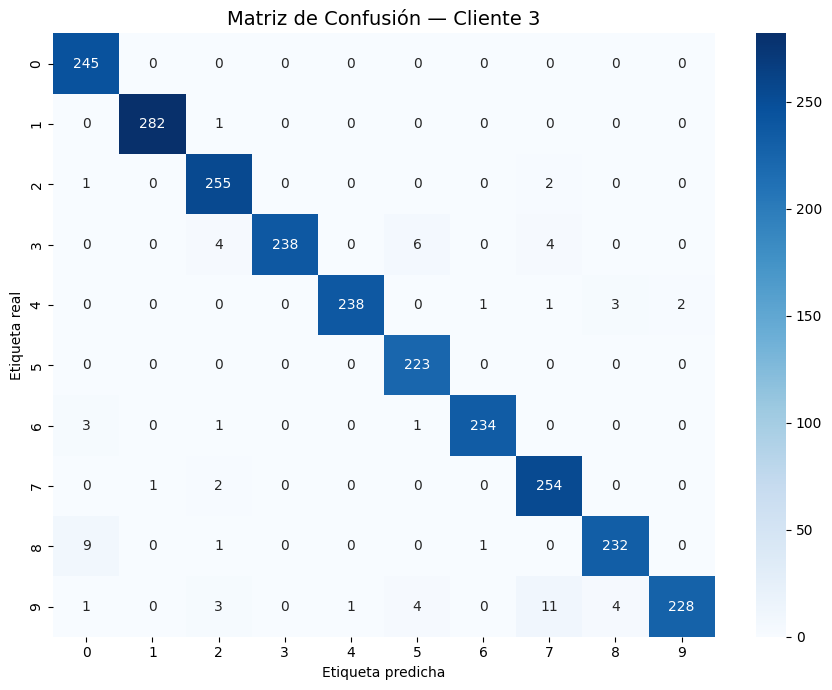

Guardada como confusion_matrix_client_3.png


In [35]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_title(f"Matriz de Confusión — Cliente {CLIENT_ID}", fontsize=14)
ax.set_ylabel("Etiqueta real")
ax.set_xlabel("Etiqueta predicha")
plt.tight_layout()
plt.savefig(f"confusion_matrix_client_{CLIENT_ID}.png", dpi=150)
plt.show()
print(f"Guardada como confusion_matrix_client_{CLIENT_ID}.png")

## 6. Guardar pesos locales para el servidor federado

In [36]:
local_weights = model.get_weights()
weights_path = f"client_{CLIENT_ID}_weights.npz"

np.savez_compressed(
    weights_path,
    **{f"layer_{i}": w for i, w in enumerate(local_weights)},
    n_samples=np.array([len(x_train)])
)

print(f"✅ Pesos locales guardados en: {weights_path}")
print(f"   Muestras de entrenamiento: {len(x_train)}")
print(f"   Número de arrays de pesos: {len(local_weights)}")
print("\nEnvía este archivo al coordinador del equipo para la agregación global.")

✅ Pesos locales guardados en: client_3_weights.npz
   Muestras de entrenamiento: 14995
   Número de arrays de pesos: 62

Envía este archivo al coordinador del equipo para la agregación global.


---
**Fin del entrenamiento local.** El archivo `client_X_weights.npz` contiene tus pesos entrenados.
Compártelo con el coordinador para ejecutar `global_aggregation.py`.